In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("CouponAcceptance.csv")

In [ ]:
df.columns

Index(['destination', 'passanger', 'weather', 'temperature', 'coupon',
       'expiration', 'gender', 'age', 'maritalStatus', 'has_children',
       'education', 'occupation', 'income', 'car', 'Bar', 'CoffeeHouse',
       'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50',
       'toCoupon_GEQ5min', 'toCoupon_GEQ15min', 'toCoupon_GEQ25min',
       'direction_same', 'direction_opp', 'Accept(Y/N?)'],
      dtype='object')

In [ ]:
df.isna().sum()/len(df)*100

,0
destination,0.000000
passanger,0.000000
weather,0.000000
temperature,0.000000
coupon,0.000000
expiration,0.000000
gender,0.000000
age,0.000000
maritalStatus,0.000000
has_children,0.000000


In [ ]:
df.drop(columns="car",inplace=True)

In [ ]:
df.dropna(inplace=True)

In [ ]:
df.rename(columns={"Accept(Y/N?)":"Accept"},inplace=True)

In [ ]:
df=pd.get_dummies(df,drop_first=True)

In [ ]:
df.shape

(12079, 89)

In [ ]:
x=df.drop(columns="Accept").values
y=df["Accept"].values

In [ ]:
# standardscaler--
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_ss=scaler.fit_transform(x)

In [ ]:
# principle component analysis
from sklearn.decomposition import PCA
pca=PCA(n_components=30)
pca_x=pca.fit_transform(x_ss)

In [ ]:
print(sum(pca.explained_variance_ratio_))

0.5867561745643148


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_ss,y,test_size=0.2)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dtc=DecisionTreeClassifier()
dtc.fit(x_train,y_train)

DecisionTreeClassifier()

In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
dtc_tr_pre=dtc.predict(x_train)
dtc_te_pre=dtc.predict(x_test)

In [ ]:
dtc_cm_tr=confusion_matrix(y_train,dtc_tr_pre)
print(dtc_cm_tr)

[[4190    0]
 [  69 5404]]


In [ ]:
dtc_cm_te=confusion_matrix(y_test,dtc_te_pre)
print(dtc_cm_te)

[[675 337]
 [443 961]]


In [ ]:
#for i in df.select_dtypes("O"):
 # print(i)

In [ ]:
# By label Encoder
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [ ]:
col=[i for i in df.columns if df[i].dtype==object]
col

[]

In [ ]:
for i in col:
  df[i]=LabelEncoder().fit_transform(df[i])

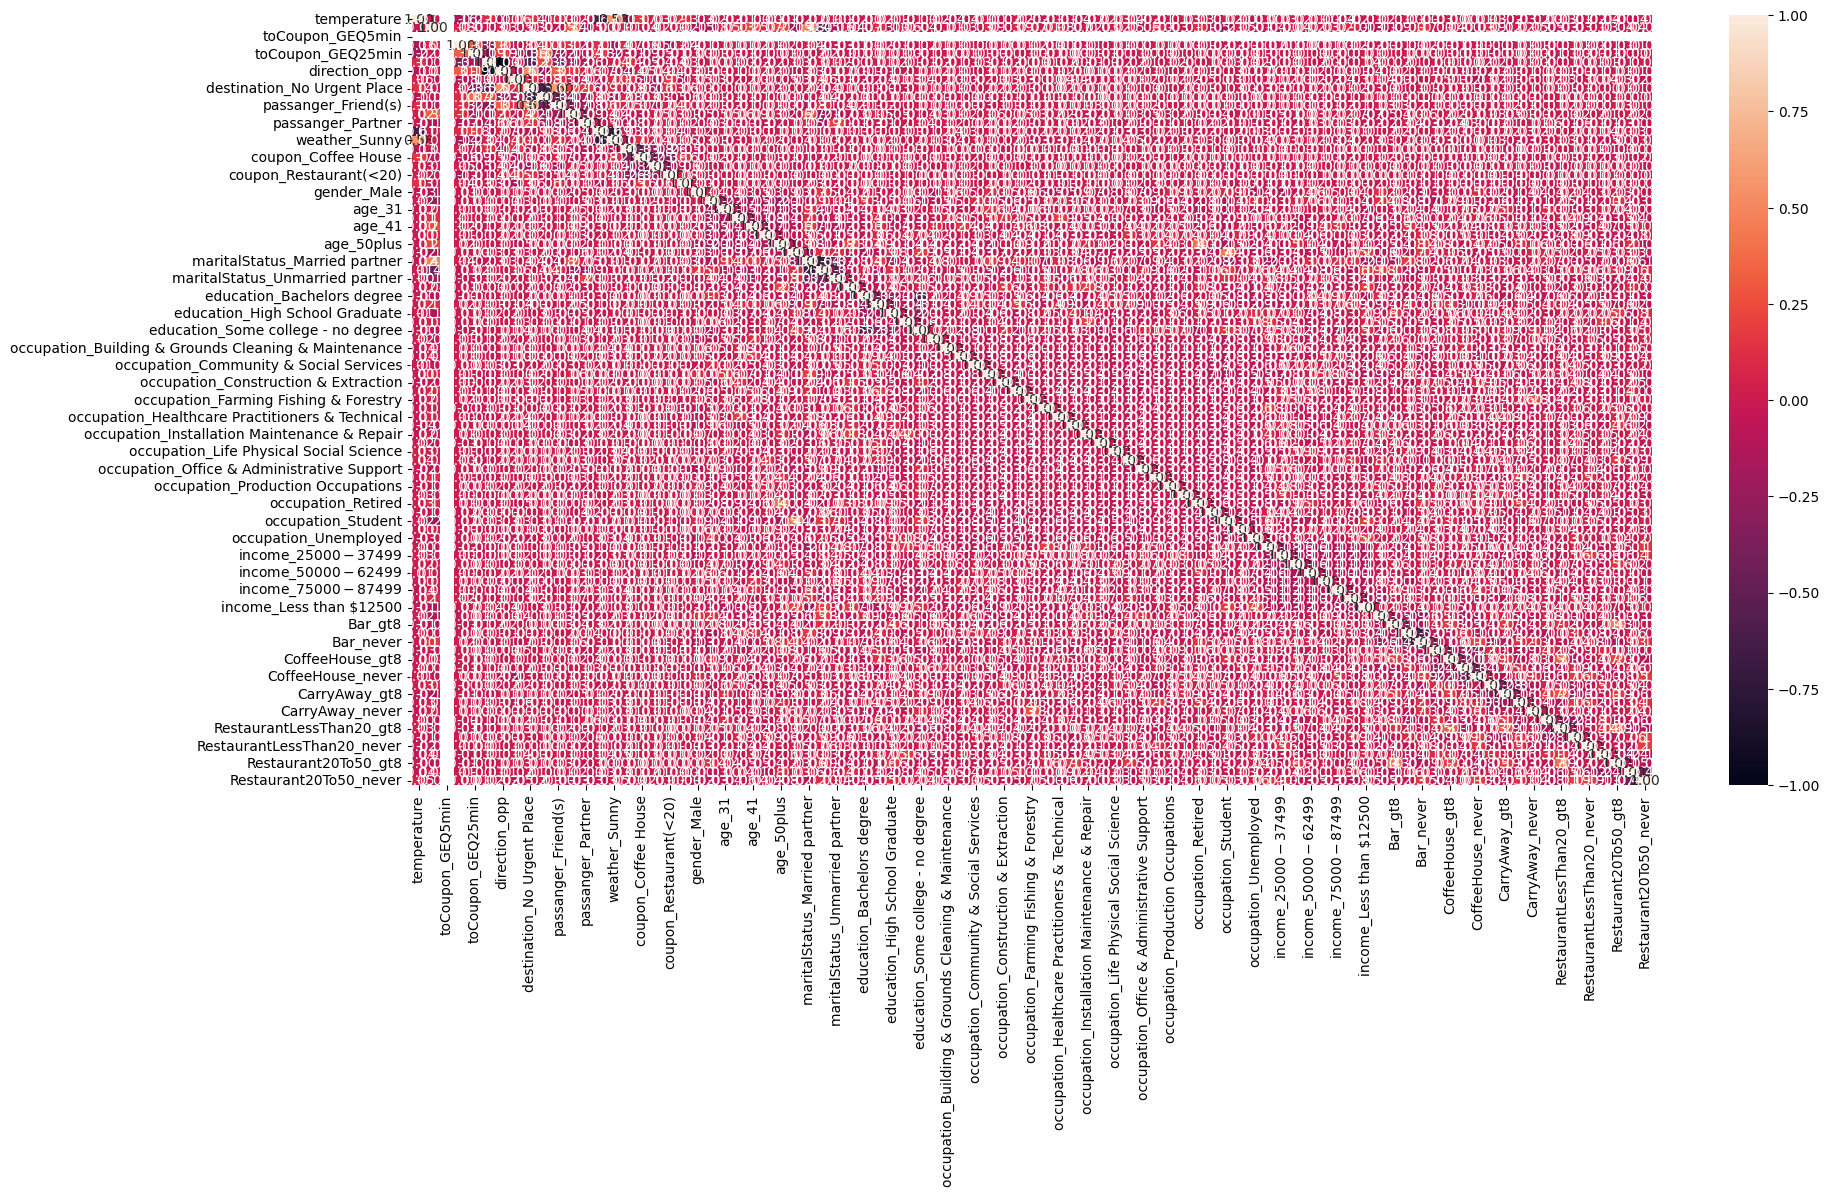

In [ ]:
plt.figure(figsize=(20,10))
sns.heatmap(df.corr(),annot=True,fmt=".2f")
plt.show()

In [ ]:
df.drop(columns="toCoupon_GEQ5min",inplace=True)

In [ ]:
x=df.drop(columns="Accept").values
y=df["Accept"].values

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.2)

In [ ]:
len(x_train)

9663

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [ ]:
# decision Tree
dtc=DecisionTreeClassifier(max_depth=240,max_features=300,max_leaf_nodes=70,min_samples_split=35,min_samples_leaf=20)
dtc.fit(x_train,y_train)
dtc_tr_pre=dtc.predict(x_train)
dtc_te_pre=dtc.predict(x_test)

In [ ]:
print("--------------------------------Accuracy Score------------------------------------")
print("Training:",dtc.score(x_train,y_train)*100)
print("Testing:",dtc.score(x_test,y_test)*100)
print("------------------------Confusion Matrix Tranning -----------------------------------")
dtc_cm_tr=confusion_matrix(y_train,dtc_tr_pre)
print(dtc_cm_tr)
print("------------------------Confusion Matrix Testing-----------------------------------")
dtc_cm_te=confusion_matrix(y_test,dtc_te_pre)
print(dtc_cm_te)
print("------------------------Classification Report Tranning-----------------------------------")
dtc_cl_tr=classification_report(y_train,dtc_tr_pre)
print(dtc_cl_tr)
print("------------------------Classification Report Testing-----------------------------------")
dtc_cl_te=classification_report(y_test,dtc_te_pre)
print(dtc_cl_te)

--------------------------------Accuracy Score------------------------------------
Training: 72.97940598157922
Testing: 71.64735099337747
------------------------Confusion Matrix Tranning -----------------------------------
[[2669 1521]
 [1090 4383]]
------------------------Confusion Matrix Testing-----------------------------------
[[ 619  393]
 [ 292 1112]]
------------------------Classification Report Tranning-----------------------------------
              precision    recall  f1-score   support

           0       0.71      0.64      0.67      4190
           1       0.74      0.80      0.77      5473

    accuracy                           0.73      9663
   macro avg       0.73      0.72      0.72      9663
weighted avg       0.73      0.73      0.73      9663

------------------------Classification Report Testing-----------------------------------
              precision    recall  f1-score   support

           0       0.68      0.61      0.64      1012
           1       0.74

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import RandomOverSampler
from collections import Counter

In [ ]:
# random forest
rfc=RandomForestClassifier(n_estimators=290,n_jobs=190,max_leaf_nodes=110,max_features=105)
rfc.fit(x_train,y_train)
rfc_tr_pre=rfc.predict(x_train)
rfc_te_pre=rfc.predict(x_test)

In [ ]:
print("----------------------------------Accuracy Score-----------------------------------")
print("Training:",rfc.score(x_train,y_train)*100)
print("Testing:",rfc.score(x_test,y_test)*100)
print("-----------------------------Confusion Matrix Tranning-----------------------------")
rfc_cm_tr=confusion_matrix(y_train,rfc_tr_pre)
print(rfc_cm_tr)
print("-----------------------------Confusion Matrix Testing------------------------------")
rfc_cm_te=confusion_matrix(y_test,rfc_te_pre)
print(rfc_cm_te)

----------------------------------Accuracy Score-----------------------------------
Training: 77.48111352582013
Testing: 74.17218543046357
-----------------------------Confusion Matrix Tranning-----------------------------
[[2766 1424]
 [ 752 4721]]
-----------------------------Confusion Matrix Testing------------------------------
[[ 619  393]
 [ 231 1173]]


In [ ]:
# random over sampler
ros=RandomOverSampler()

In [ ]:
Counter(y_train)

Counter({np.int64(1): 5473, np.int64(0): 4190})

In [ ]:
x_train_ros,y_train_ros=ros.fit_resample(x_train,y_train)

In [ ]:
Counter(y_train_ros)

Counter({np.int64(1): 5473, np.int64(0): 5473})

In [ ]:
rfc.fit(x_train_ros,y_train_ros)

RandomForestClassifier(max_features=355, max_leaf_nodes=180, n_estimators=200,
                       n_jobs=100)

In [ ]:
print("Trainig:",rfc.score(x_train_ros,y_train_ros)*100)
print("Testing:",rfc.score(x_test,y_test)*100)

Trainig: 80.35812168828797
Testing: 73.09602649006622


In [ ]:
# logistic regression

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
from sklearn.linear_model import LogisticRegression
lrc=LogisticRegression(penalty="l1",solver="liblinear",C=0.01)
# for elastic net regularition the solver is "saga"
lrc.fit(x_train,y_train)

LogisticRegression(C=0.01, penalty='l1', solver='liblinear')

In [ ]:
print("train:",lrc.score(x_train,y_train)*100)
print("test:",lrc.score(x_test,y_test)*100)

train: 65.70423263996689
test: 66.92880794701986


In [ ]:
lr_tr_pre=lrc.predict(x_train)
lr_te_pre=lrc.predict(x_test)

In [ ]:
lr_cm_tr=confusion_matrix(y_train,lr_tr_pre)
lr_cm_tr

array([[1812, 2378],
       [ 936, 4537]])

In [ ]:
lr_cm_te=confusion_matrix(y_test,lr_te_pre)
lr_cm_te

array([[ 449,  563],
       [ 236, 1168]])

In [ ]:
lr_cl_tr=classification_report(y_train,lr_tr_pre)
print(lr_cl_tr)

              precision    recall  f1-score   support

           0       0.66      0.43      0.52      4190
           1       0.66      0.83      0.73      5473

    accuracy                           0.66      9663
   macro avg       0.66      0.63      0.63      9663
weighted avg       0.66      0.66      0.64      9663



In [ ]:
lr_cl_te=classification_report(y_test,lr_te_pre)
print(lr_cl_te)

              precision    recall  f1-score   support

           0       0.66      0.44      0.53      1012
           1       0.67      0.83      0.75      1404

    accuracy                           0.67      2416
   macro avg       0.67      0.64      0.64      2416
weighted avg       0.67      0.67      0.65      2416

